<a href="https://colab.research.google.com/github/sorotdaniel/portfolio-soro/blob/main/telecom_churn_viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualisation avancée interactive — `telecom_churn.csv`

Cette seance a pour but de faire connaissance de la librairie plotly.
Vous trouvérez les différentes visualisations et les codes sur https://plotly.com/python/

**Instructions d'utilisation**:
- Nous essayons d"apliquer certaines notions et visualisation au dataset `telecom_churn.csv` téléchargé sur kaggle.
- Les différentes variables se trouvant dans le dataset sont les suivantes:
  
| Colonne                                | Description                                                 |
| -------------------------------------- | ----------------------------------------------------------- |
| **State**                              | État de résidence du client (ex. TX, NY, CA...)             |
| **Account length**                     | Nombre de jours depuis la création du compte                |
| **Area code**                          | Code régional téléphonique (ex. 408, 415, 510)              |
| **International plan**                 | Indique si le client a un plan d’appels internationaux      |
| **Voice mail plan**                    | Indique si le client a un service de messagerie vocale      |
| **Number vmail messages**              | Nombre de messages vocaux laissés                           |
| **Total day minutes**                  | Minutes d’appel en journée                                  |
| **Total day calls**                    | Nombre d’appels en journée                                  |
| **Total day charge**                   | Facturation des appels en journée                           |
| **Total eve minutes**                  | Minutes d’appel en soirée                                   |
| **Total eve calls**                    | Nombre d’appels en soirée                                   |
| **Total eve charge**                   | Facturation des appels en soirée                            |
| **Total night minutes**                | Minutes d’appel la nuit                                     |
| **Total night calls**                  | Nombre d’appels la nuit                                     |
| **Total night charge**                 | Facturation des appels la nuit                              |
| **Total intl minutes**                 | Minutes d’appels internationaux                             |
| **Total intl calls**                   | Nombre d’appels internationaux                              |
| **Total intl charge**                  | Facturation des appels internationaux                       |
| **Customer service calls**             | Nombre d’appels passés au service client                    |
| **Churn**                              | Variable cible : indique si le client a quitté l’entreprise |

## 1) Imports et installation

Cette cellule installe et importe les bibliothèques principales : plotly, ipywidgets, scikit-learn pour quelques transformations, et seaborn pour comparaisons statiques.

Explications en ligne dans le code.

# 1️ plotly.express
## idéale pour explorer les données sans trop de code.
     Ce qu’elle permet :

## Créer des graphes interactifs:

     px.scatter : nuage de points

     px.bar : diagramme en barres

     px.box : boîte à moustaches

     px.sunburst : diagramme en soleil

     px.scatter_matrix() : matrice de corrélations interactive

# 2️ plotly.graph_objects (alias go)
## Elle offre un contrôle total sur la structure du graphique : axes, annotations, styles, animations, etc.

# 3 IPython.display (et display)
## Utilisée pour afficher dynamiquement du contenu dans les notebooks.
     Afficher des objets interactifs (widgets, graphiques, HTML…)
     Mettre à jour une sortie sans relancer tout le notebook

# 4 ipywidgets
## C’est la bibliothèque principale pour créer des interfaces interactives dans les notebooks Jupyter.
## permet :

## Ajouter des contrôles interactifs :
      menu déroulant
      curseur numérique
      bouton d’action

In [135]:
# Installer les paquets manquants si besoin
!pip install plotly ipywidgets pandas scikit-learn notebook

import os
import pandas as pd
import numpy as np
pd.DataFrame.iteritems = pd.DataFrame.items  # compatibilité Pandas 2.0+
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display
import ipywidgets as widgets
import seaborn as sns

print("Versions:")
import plotly
import sklearn
print("pandas", pd.__version__)
print("plotly", plotly.__version__)
print("sklearn", sklearn.__version__)


Versions:
pandas 2.2.2
plotly 5.24.1
sklearn 1.6.1


## 2) Chargement du dataset

Placez `telecom_churn.csv` dans le répertoire courant, ou modifiez le chemin ci-dessous. Nous afficherons les premières lignes et les informations générales.

In [136]:
# Modifier le chemin si besoin
path = "telecom_churn.csv"

df = pd.read_csv(path)
print("Dimensions:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Dimensions: (3333, 21)


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
state,3333,51,WV,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account length,3333.0,NaN,NaN,NaN,101.064806,39.822106,1.0,74.0,101.0,127.0,243.0
area code,3333.0,NaN,NaN,NaN,437.182418,42.37129,408.0,408.0,415.0,510.0,510.0
phone number,3333,3333,400-4344,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
international plan,3333,2,no,3010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
voice mail plan,3333,2,no,2411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number vmail messages,3333.0,NaN,NaN,NaN,8.09901,13.688365,0.0,0.0,0.0,20.0,51.0
total day minutes,3333.0,NaN,NaN,NaN,179.775098,54.467389,0.0,143.7,179.4,216.4,350.8
total day calls,3333.0,NaN,NaN,NaN,100.435644,20.069084,0.0,87.0,101.0,114.0,165.0
total day charge,3333.0,NaN,NaN,NaN,30.562307,9.259435,0.0,24.43,30.5,36.79,59.64


## 3) Nettoyage rapide et préparation

Nous gérons les valeurs manquantes, convertissons les colonnes numériques mal typées et ajoutons quelques colonnes utiles (par ex. `tenure_group`).

In [137]:
# Exécuter après avoir chargé `df`
try:
    df
except NameError:
    raise RuntimeError("Chargez d'abord le dataset (exécutez la cellule de chargement).")

# Copier pour travailler pour ne pas perdre les données originales
data = df.copy()

# Identifier colonnes manquantes
missing = data.isna().sum()
print("Valeurs manquantes (top 20):")
print(missing[missing>0].sort_values(ascending=False).head(20))


# Convertir les colonnes object représentant des nombres
for col in data.columns:
    if data[col].dtype == 'object':
        # tenter de convertir en numérique quand pertinent
        try:
            data[col] = pd.to_numeric(data[col])
        except:
            pass

# Exemple: créer un groupe de tenure
if 'tenure' in data.columns:
    bins = [0, 6, 12, 24, 48, 72, 1000]
    labels = ['0-6','7-12','13-24','25-48','49-72','73+']
    data['tenure_group'] = pd.cut(data['tenure'], bins=bins, labels=labels, include_lowest=True)

# Assurer target binaire nommée 'Churn' ou 'churn' -> standardiser
possible_targets = [c for c in data.columns if c.lower() in ['churn','churn?','churn_flag','exited']]
if possible_targets:
    target = possible_targets[0]
    print("Colonne cible détectée:", target)
    data.rename(columns={target: 'Churn'}, inplace=True)
else:
    print("Aucune colonne cible évidente détectée. Si votre fichier contient la colonne cible, renommez-la en 'Churn' ou signalez-moi le nom exact.")

# Afficher quelques lignes
display(data.head())


Valeurs manquantes (top 20):
Series([], dtype: int64)
Colonne cible détectée: churn


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 4) Visualisation interactive : distribution du churn

Explication : commencer par regarder la proportion de clients perdus (Churn) — base pour interpréter toutes les autres visualisations. Utilisons Plotly pour des graphiques interactifs, et ipywidgets pour contrôles.

<Axes: ylabel='count'>

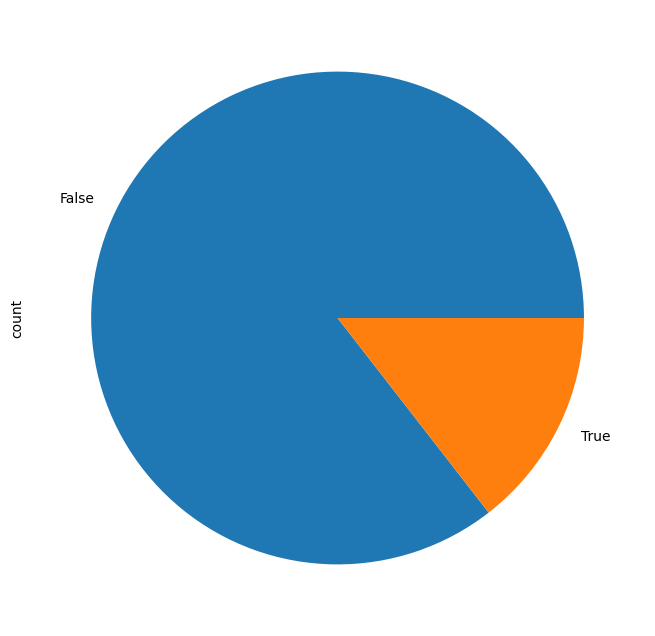

In [138]:
df['churn'].value_counts().plot.pie( figsize= (10,8))


In [139]:
# Distribution du churn
if 'churn' in data.columns:
    # tenter de normaliser Churn si c'est 'Yes'/'No'
    if data['Churn'].dtype == 'object':
        data['Churn'] = data['Churn'].map(lambda x: 1 if str(x).lower() in ['yes','y','true','1'] else 0)
    fig = px.pie(data, names='Churn', title='Proportion de Churn', hole=0.4)
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.update_layout(width=900, height=600)
    fig.show()
else:
    print("Colonne 'Churn' manquante — voir cellule de nettoyage.")


Colonne 'Churn' manquante — voir cellule de nettoyage.


In [140]:

fig = px.pie(df, values='customer service calls', names='number vmail messages', title='Nombres de minutes de nuit par Etat')
#fig.update_layout(width=1000, height=600)
fig.update_layout(width=800, height=800)
fig.show()

## Pour afficher toutes les lignes ou/et toutes les colonnes.
** Fraire attention au grand volume de données avec les lignes**

In [141]:
#pd.set_option('display.max_row', None)
pd.set_option('display.max_columns', None)

In [142]:
data.groupby(['state' ]).agg({'customer service calls': ['sum']}).sort_values(by=( 'customer service calls', 'sum'), ascending= False).head()

,customer service calls
,sum
state,
WV,159
NY,142
OR,135
MN,130
VT,127


In [143]:
# On affiche le pourcentage des clients de l'Etat WV ayant fait contacté le centre d'appel
print(round(159/df['customer service calls'].sum(), 4)*100,'%')

3.05 %


In [144]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [145]:
# Regroupons les clients par nombres d'appels effectué au service client.
df['customer service calls'].value_counts()

,count
customer service calls,
1,1181
2,759
0,697
3,429
4,166
5,66
6,22
7,9
9,2


In [146]:
data.groupby(['state' ]).agg({'total day minutes': ['count','sum']}).sort_values(by=( 'total day minutes', 'sum'), ascending= False).head()
#df['total day minutes'].value_counts()

total day minutes         
                  count      sum
state                           
WV                  106  18438.8
MN                   84  15401.8
AL                   80  14880.8
NY                   83  14534.5
OH                   78  14295.4

# Diagramme circulaire hiérarchique  

In [147]:
import plotly.express as px

# Exemple : Visualisation hiérarchique du churn
fig = px.sunburst(
    data,  # ton DataFrame
    path=[ 'voice mail plan', 'Churn','state'],  # hiérarchie des niveaux
    values='total day minutes',  # une variable numérique à agréger (à adapter selon ton dataset)
    color='Churn',  # variable pour la coloration
    #color_discrete_map={'Yes': 'red', 'No': 'green'},
    title="Structure hiérarchique du churn par plan vocal et par État"
)
fig.update_layout(width=900, height=600)
fig.show()

# Histogramme et densité

In [148]:
import plotly.figure_factory as ff
df = data
col_reel= ['total day minutes', 'total day calls', 'total day charge']
fig = ff.create_distplot([df[c] for c in col_reel], col_reel, bin_size=.50)
fig.update_layout(width=1000, height= 800)
fig.show()

In [149]:
df['total day calls'].median()

101.0

## 5) Scatter matrix interactif / pairplot sélectif

Explication : comparer plusieurs variables numériques simultanément pour repérer des relations, clusters, ou patterns liés au churn. Le scatter matrix interactif avec Plotly permet le zoom et le hover.

In [150]:
# Sélection de colonnes numériques utiles
num_cols = data.select_dtypes(include=np.number).columns.tolist()
candidates = [c for c in num_cols if c.lower() not in ('customerid','id','index')]
short = candidates[:8]  # limiter pour performance

print("colonnes numériques candidates (premières):", short)

# Widget pour sélectionner colonnes à inclure
cols_select = widgets.SelectMultiple(
    options=candidates,
    value=short,
    description='Features',
    rows=8
)

def plot_pair(change=None):
    cols = list(cols_select.value)
    if len(cols) < 2:
        print("Sélectionnez au moins 2 colonnes numériques.")
        return
    fig = px.scatter_matrix(data, dimensions=cols, color='Churn' if 'Churn' in data.columns else None,
                            title='Scatter matrix interactif')
    fig.update_traces(diagonal_visible=False)
    fig.update_layout(width=1200, height=1000)
    fig.show()

btn = widgets.Button(description="Tracer scatter matrix")
out = widgets.Output()

def on_click(b):
    with out:
        out.clear_output(wait=True)
        plot_pair()

btn.on_click(on_click)
display(widgets.HBox([cols_select, btn]))
display(out)


colonnes numériques candidates (premières): ['account length', 'area code', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls']


Output()

## 6) Heatmap de corrélation interactive

Explication : repérer les relations linéaires fortes entre variables numériques et la cible (si encodée numériquement).

In [151]:
# Corrélation et heatmap
numeric = data.select_dtypes(include=np.number)
corr = numeric.corr()
print("Matrice de corrélation (extrait):")
display(corr.loc[:, :])

# Heatmap avec Plotly
fig = go.Figure(data=go.Heatmap(z=corr.values,
                                x=corr.columns,
                                y=corr.index,
                                colorbar=dict(title='corr')))
fig.update_layout(title='Heatmap de corrélation interactive',width=1000, height=800)

fig.show()


Matrice de corrélation (extrait):


,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
account length,1.000000,-0.012463,-0.004628,0.006216,0.038470,0.006214,-0.006757,0.019260,-0.006745,-0.008955,-0.013176,-0.008960,0.009514,0.020661,0.009546,-0.003796
area code,-0.012463,1.000000,-0.001994,-0.008264,-0.009646,-0.008264,0.003580,-0.011886,0.003607,-0.005825,0.016522,-0.005845,-0.018288,-0.024179,-0.018395,0.027572
number vmail messages,-0.004628,-0.001994,1.000000,0.000778,-0.009548,0.000776,0.017562,-0.005864,0.017578,0.007681,0.007123,0.007663,0.002856,0.013957,0.002884,-0.013263
total day minutes,0.006216,-0.008264,0.000778,1.000000,0.006750,1.000000,0.007043,0.015769,0.007029,0.004323,0.022972,0.004300,-0.010155,0.008033,-0.010092,-0.013423
total day calls,0.038470,-0.009646,-0.009548,0.006750,1.000000,0.006753,-0.021451,0.006462,-0.021449,0.022938,-0.019557,0.022927,0.021565,0.004574,0.021666,-0.018942
total day charge,0.006214,-0.008264,0.000776,1.000000,0.006753,1.000000,0.007050,0.015769,0.007036,0.004324,0.022972,0.004301,-0.010157,0.008032,-0.010094,-0.013427
total eve minutes,-0.006757,0.003580,0.017562,0.007043,-0.021451,0.007050,1.000000,-0.011430,1.000000,-0.012584,0.007586,-0.012593,-0.011035,0.002541,-0.011067,-0.012985
total eve calls,0.019260,-0.011886,-0.005864,0.015769,0.006462,0.015769,-0.011430,1.000000,-0.011423,-0.002093,0.007710,-0.002056,0.008703,0.017434,0.008674,0.002423
total eve charge,-0.006745,0.003607,0.017578,0.007029,-0.021449,0.007036,1.000000,-0.011423,1.000000,-0.012592,0.007596,-0.012601,-0.011043,0.002541,-0.011074,-0.012987
total night minutes,-0.008955,-0.005825,0.007681,0.004323,0.022938,0.004324,-0.012584,-0.002093,-0.012592,1.000000,0.011204,0.999999,-0.015207,-0.012353,-0.015180,-0.009288


## 7) Exploration des variables catégorielles

Explication : pour chaque variable catégorielle, comparer la distribution et le churn rate — utilisons un widget pour choisir la colonne et afficher plusieurs graphiques complémentaires.

In [152]:

# Détection des colonnes catégorielles
cat_cols = data.select_dtypes(include='object').columns.tolist() + data.select_dtypes('category').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Churn']
print("Colonnes catégorielles détectées (extrait):", cat_cols[:20])

col_dropdown = widgets.Dropdown(options=cat_cols, description='Catégorie:')
out_cat = widgets.Output()

def plot_cat(change=None):
    with out_cat:
        out_cat.clear_output(wait=True)
        col = col_dropdown.value
        if not col:
            print("Aucune colonne sélectionnée.")
            return

        # Normalisation de la colonne Churn
        if 'Churn' in data.columns:
            data['Churn'] = data['Churn'].astype(str).str.strip().str.capitalize()
            data['Churn'] = data['Churn'].replace({'1': 'Yes', '0': 'No', 'True': 'Yes', 'False': 'No'})

        # --- Histogramme par catégorie
        fig1 = px.histogram(
            data, x=col, color='Churn' if 'Churn' in data.columns else None,
            barmode='group',
            title=f'Comptes par modalité: {col}'
        )
        fig1.update_layout(xaxis_tickangle=-45)
        fig1.show()

        # --- Taux de churn par modalité
        if 'Churn' in data.columns:
            churn_col = data['Churn']
            if churn_col.dtype in [np.int64, np.float64]:
                grp = data.groupby(col)['Churn'].mean().reset_index(name='churn_rate')
            else:
                grp = data.groupby(col)['Churn'].apply(
                    lambda x: (x.astype(str).str.lower() == 'yes').mean()
                ).reset_index(name='churn_rate')

            # Vérification pour éviter un graphique vide
            if grp['churn_rate'].isnull().all() or grp['churn_rate'].sum() == 0:
                print(" Aucun churn détecté — vérifie la colonne 'Churn'")
            else:
                fig2 = px.bar(
                    grp, x=col, y='churn_rate',
                    title=f'Taux de churn par modalité ({col})',
                    labels={'churn_rate': 'Taux de churn'}
                )
                fig2.update_layout(xaxis_tickangle=-45, yaxis_tickformat=".0%")
                fig2.show()

        # --- Distribution numérique (optionnelle)
        numeric = data.select_dtypes(include=np.number)
        if not numeric.empty:
            numcol = numeric.columns[0]
            fig3 = px.violin(
                data, x=col, y=numcol,
                color='Churn' if 'Churn' in data.columns else None,
                box=True, points='all',
                title=f'Distribution de {numcol} par modalité de {col}'
            )
            fig3.update_layout(xaxis_tickangle=-25)
            fig3.show()

# Lier le menu déroulant à la fonction
col_dropdown.observe(plot_cat, names='value')
display(col_dropdown, out_cat)


Colonnes catégorielles détectées (extrait): ['state', 'phone number', 'international plan', 'voice mail plan']


Dropdown(description='Catégorie:', options=('state', 'phone number', 'international plan', 'voice mail plan'),…

Output()

# 8 Test d'hypothèse
## Est-ce que les clients avec un plan d’appel international résilient plus souvent que les autres ?
## le plan d’appel international influence-t-il la résiliation d’un client?
### H0: Il n’y a aucune relation entre le plan international et le churn.
### Autrement, le churn est indépendant du plan international.


In [153]:
import pandas as pd
from scipy.stats import chi2_contingency

# Exemple : table de contingence
table = pd.crosstab(data['international plan'], data['Churn'])
print(table)

Churn               False  True 
international plan              
no                   2664    346
yes                   186    137


In [154]:
# Test du Chi-deux
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi² = {chi2:.2f}")
print(f"p-value = {p:.4f}")

Chi² = 222.57
p-value = 0.0000


In [155]:
# valeurs attendus si H0 est vraie.
expected

array([[2573.80738074,  436.19261926],
       [ 276.19261926,   46.80738074]])

# On a bien p inferieur à 0.05 donc le désabonnement des cleints depend du plan international.

In [156]:
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


## 10) Tableau de bord combiné (exemple)

Objectif : combiner plusieurs widgets pour un mini-dashboard — filtre par tenure, abonnement, ou autre, et mise à jour de graphiques liés.

In [157]:
# Exemple de mini-dashboard
filters = {}
# Choisir un cat feature existante
cat_candidates = [c for c in data.columns if data[c].nunique() < 20 and data[c].dtype == 'object']
if cat_candidates:
    cat0 = cat_candidates[0]
else:
    cat0 = None

tenure_opt = ['All']
if 'tenure_group' in data.columns:
    tenure_opt = ['All'] + list(data['tenure_group'].cat.categories.astype(str))

w_tenure = widgets.Dropdown(options=tenure_opt, description='Tenure:')
w_cat = widgets.Dropdown(options=['All'] + (list(data[cat0].unique()) if cat0 else []), description=f'{cat0}:')

out_dash = widgets.Output()

def update_dashboard(_=None):
    with out_dash:
        out_dash.clear_output(wait=True)
        df_f = data.copy()
        if w_tenure.value != 'All' and 'tenure_group' in df_f.columns:
            df_f = df_f[df_f['tenure_group'].astype(str) == w_tenure.value]
        if cat0 and w_cat.value != 'All':
            df_f = df_f[df_f[cat0] == w_cat.value]
        # Charts
        if 'Churn' in df_f.columns:
            fig1 = px.histogram(df_f, x='Churn', title='Distribution Churn (filtrée)')
            fig1.show()
        # Numeric summary
        #display(df_f.select_dtypes(include=np.number).describe().T.head(10))

w_tenure.observe(update_dashboard, names='value')
w_cat.observe(update_dashboard, names='value')
display(widgets.HBox([w_tenure, w_cat]), out_dash)
# Initial call
update_dashboard()


Output()